# Latent-driver benchmark — D2Deep, GEMME, AlphaMissense, EVE, FATHMM-cancer

Positives = latent-driver doublets, negatives = gnomAD frequent-pair doublets, per gene.
Each predictor uses its own threshold + polarity:

| predictor | unit | threshold | higher=driver |
|---|---|---|---
| D2Deep | doublet | sigmoid 0.5 | yes |
| GEMME | doublet | per-protein midpoint | yes |
| AlphaMissense | single→agg | 0.564 | yes |
| EVE | single→agg | 0.75 | yes | evemodel.org |
| ESM-1v | single→agg | midpoint | no (lower=driver) |
| FATHMM-cancer | single→agg | −0.75 | no (lower=driver) |

AM/EVE aggregate two single scores (mean). Validated set = the 155 pairs in `validated_latent.csv`.

## 0. Setup + config

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, re, gc, sys, glob, requests
import numpy as np, pandas as pd, torch, torch.nn as nn
from sklearn.metrics import f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt, seaborn as sns

BASE = '/content/drive/MyDrive/Colab Notebooks/5thYear/latent_driver_pairs'
LATENT_D2D  = f'{BASE}/latent_driver_pairs/D2D_features'
GNOMAD_D2D  = f'{BASE}/gnomAD/frequent_latent_pairs_D2D_features'
LATENT_GEMME= f'{BASE}/latent_driver_pairs/GEMME'
GNOMAD_GEMME= f'{BASE}/gnomAD/frequent_latent_pairs_GEMME_output'
MART_FILE='/content/drive/MyDrive/mart_refseq_swiss_isoform.txt'
AM_TSV      = '/content/drive/MyDrive/AlphaMissense_aa_substitutions.tsv' # to be downloaded from https://zenodo.org/records/8208688
EVE_DIR     = '/content/drive/MyDrive/EVE_scores/'
D2D_MODEL   = '/content/drive/MyDrive/my_colab/3rdYear/GMM/model'
VALIDATED_FILE='/content/drive/MyDrive/D2D_paper/review_CSBJ/validated_latent.csv'   # the 155 pairs


AGG_RULE='mean'; N_PAD=2200
GEMME_HIGHER_IS_DRIVER=True; GEMME_SCORE_COL='NA'

FATHMM_OUTPUT='/content/drive/MyDrive/D2D_paper/review_CSBJ/fathmm_output_pos_neg.txt'   # tab-delimited results from fathmm.biocompute.org.uk

RULES={'D2Deep':('sigmoid',None),'GEMME':('midpoint',None),
       'AlphaMissense':('fixed',0.564),'EVE':('fixed',0.75),
       'FATHMM_cancer':('fixed',-0.75)}
HIGHER={'D2Deep':True,'GEMME':GEMME_HIGHER_IS_DRIVER,'AlphaMissense':True,'EVE':True,
        'FATHMM_cancer':False}   # lower=more deleterious/cancer
# predictors carrying a per-MUTATION column in rec (used by the validated-pair eval)
RECORD_COLS={'AlphaMissense':'AM','EVE':'EVE','FATHMM_cancer':'FATHMM_cancer','D2Deep':'D2Deep'}
device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## 1. UniProt→gene + parse mutations

In [ ]:
mart=pd.read_csv(MART_FILE,sep='\t',dtype=str).fillna(''); mart.columns=['refseq','gene','swiss','isoform']
uni2gene={}
for r in mart.itertuples(index=False):
    if not r.gene: continue
    if r.swiss: uni2gene.setdefault(r.swiss,r.gene)
    if r.isoform:
        uni2gene.setdefault(r.isoform,r.gene); uni2gene.setdefault(r.isoform.split('-')[0],r.gene)

_S=re.compile(r'^([A-Z])(\d+)([A-Z])$')
def parse_mutation(s):
    acc,rest=s.split('_',1); comps=[]
    for part in rest.split(':'):
        m=_S.match(part.strip()); comps.append((m.group(1),int(m.group(2)),m.group(3)))
    return acc,comps

## 2. Read both D2D_features dirs → record spine

In [ ]:
def read_dir(d,label):
    recs,skip=[],set()
    for path in sorted(glob.glob(os.path.join(d,'*.csv'))):
        df=pd.read_csv(path,usecols=lambda c:c=='mutation')
        if 'mutation' not in df.columns: continue
        for mut in df['mutation']:
            acc,comps=parse_mutation(mut); gene=uni2gene.get(acc) or uni2gene.get(acc.split('-')[0])
            if gene is None: skip.add(acc); continue
            recs.append({'label':label,'acc':acc,'am_acc':acc.split('-')[0],'gene':gene,
                         'eve':f'{gene}_HUMAN','mutation':mut,'comps':comps})
    if skip: print('ignored (not in BioMart):',sorted(skip)[:8])
    return recs
rec=pd.DataFrame(read_dir(LATENT_D2D,1)+read_dir(GNOMAD_D2D,0))
print('records:',len(rec),'| by label:',rec.label.value_counts().to_dict(),'| genes:',rec.gene.nunique())

records: 68951 | by label: {1: 38988, 0: 29963} | genes: 28


## 3. AlphaMissense (single→aggregate)

In [ ]:
need=set(rec['am_acc'].unique()); parts=[]
for ch in pd.read_csv(AM_TSV,sep='\t',comment='#',usecols=['uniprot_id','protein_variant','am_pathogenicity'],chunksize=2_000_000):
    h=ch[ch['uniprot_id'].isin(need)];
    if len(h): parts.append(h)
    gc.collect()
al=pd.concat(parts,ignore_index=True) if parts else pd.DataFrame(columns=['uniprot_id','protein_variant','am_pathogenicity'])
AM={f'{u}_{v}':s for u,v,s in al.itertuples(index=False)}
def agg(v):
    v=[x for x in v if x is not None and not (isinstance(x,float) and np.isnan(x))]
    return np.nan if not v else {'max':max,'mean':np.mean,'min':min,'sum':sum}[AGG_RULE](v)
def am_single(acc,w,p,a): return AM.get(f'{acc}_{w}{p}{a}',np.nan)
rec['AM']=[agg([am_single(r.am_acc,*c) for c in r.comps]) for r in rec.itertuples(index=False)]
print('AM coverage:',round(float(rec.AM.notna().mean()),3),'| missing acc:',sorted(need-set(al.uniprot_id.unique())))

AM coverage: 1.0 | missing acc: []


## 4. EVE (single→aggregate)

In [ ]:
os.makedirs(EVE_DIR,exist_ok=True); _eve={}
def eve_table(name):
    if name not in _eve:
        p=os.path.join(EVE_DIR,f'{name}.csv')
        if not os.path.exists(p): _eve[name]=None
        else:
            x=pd.read_csv(p); sc=next(c for c in x.columns if c.lower().startswith('eve_scores_asm'))
            x['k']=x['wt_aa']+x['position'].astype(str)+x['mt_aa']; _eve[name]=dict(zip(x['k'],x[sc]))
    return _eve[name]
def eve_single(name,w,p,a):
    t=eve_table(name); return np.nan if t is None else t.get(f'{w}{p}{a}',np.nan)
rec['EVE']=[agg([eve_single(r.eve,*c) for c in r.comps]) for r in rec.itertuples(index=False)]
print('EVE coverage:',round(float(rec.EVE.notna().mean()),3))

/tmp/ipykernel_985/490279863.py:7: DtypeWarning: Columns (12,13,14,15,16,17,18,19,20,21,22,26) have mixed types. Specify dtype option on import or set low_memory=False.
  x=pd.read_csv(p); sc=next(c for c in x.columns if c.lower().startswith('eve_scores_asm'))


EVE coverage: 0.325


## 4. FATHMM-cancer (single→aggregate, web batch)

FATHMM scores single substitutions, so the input is every substitution at each position (the components
of your 19×19 doublet grid). Run cell A to write the input, submit it at fathmm.biocompute.org.uk with
**Cancer** weights, download the tab-delimited results, then run cell B. Score < −0.75 = cancer-associated,
so lower = driver.

In [ ]:
# A) FATHMM input: unique single substitutions across ALL doublets (latent + gnomAD)
singles=sorted({(r.acc,)+c for r in rec.itertuples(index=False) for c in r.comps})
with open('/content/drive/MyDrive/D2D_paper/review_CSBJ/fathmm_input_pos_neg.txt','w') as f:
    for acc,w,p,a in singles: f.write(f'{acc} {w}{p}{a}\n')
print(len(singles),'substitutions -> /content/drive/MyDrive/D2D_paper/review_CSBJ/fathmm_input_pos_neg.txt')
from google.colab import files as _files; _files.download('/content/drive/MyDrive/D2D_paper/review_CSBJ/fathmm_input_pos_neg.txt')

4560 substitutions -> /content/drive/MyDrive/D2D_paper/review_CSBJ/fathmm_input_pos_neg.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# B) parse FATHMM results -> per-doublet aggregate
FATHMM_SC={}
if os.path.exists(FATHMM_OUTPUT):
    fa=pd.read_csv(FATHMM_OUTPUT,sep='\t')
    pcol=next(c for c in fa.columns if 'protein' in c.lower())
    subcol=next(c for c in fa.columns if 'substitution' in c.lower())
    scol=next(c for c in fa.columns if c.strip().lower()=='score')
    for prot,sub,sc in zip(fa[pcol],fa[subcol],fa[scol]):
        m=re.match(r'([A-Z])(\d+)([A-Z])',str(sub))
        if m and pd.notna(sc):
            try: FATHMM_SC[(prot,m.group(1),int(m.group(2)),m.group(3))]=float(sc)
            except ValueError: pass
    print('FATHMM scores parsed:',len(FATHMM_SC))
else:
    print('FATHMM output not found -> all NaN. Submit fathmm_input.txt and set FATHMM_OUTPUT.')
def fathmm_single(acc,w,p,a): return FATHMM_SC.get((acc,w,p,a),np.nan)
rec['FATHMM_cancer']=[agg([fathmm_single(r.acc,*c) for c in r.comps]) for r in rec.itertuples(index=False)]
print('FATHMM coverage:',round(float(rec.FATHMM_cancer.notna().mean()),3))

FATHMM scores parsed: 4123
FATHMM coverage: 0.927


## 5. GEMME + D2Deep

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, Dataset, WeightedRandomSampler

In [ ]:
class Classifier2L(nn.Module):
    def __init__(self, hidden, hidden2, dropout=0):
        super(Classifier2L, self).__init__()
        self.hidden = hidden
        self.hidden2 = hidden2
        self.num_feature = 2200
        self.dropout = dropout
        self.batchnorm1 = nn.BatchNorm1d(self.hidden)
        self.batchnorm2 = nn.BatchNorm1d(self.hidden2)

        self.layer_1 = nn.Linear(self.num_feature,  self.hidden)
        self.layer_2 = nn.Linear( self.hidden, self.hidden2)
        self.layer_3 = nn.Linear( self.hidden2, 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.batchnorm1(x)
        x= self.dropout(x)
        x = self.relu(x)

        x = self.layer_2(x)
        x = self.batchnorm2(x)
        x = self.relu(x)
        x= self.dropout(x)

        x = self.layer_3(x)
        #x = self.sigmoid(x)

        return x


    def compute_l1_loss(self, w):
        return torch.abs(w).sum()

    def compute_l2_loss(self, w):
        return torch.square(w).sum()


class ClassifierDataset(Dataset):

    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]

    def __len__ (self):
        return len(self.X_data)

In [ ]:
def gemme_scores(uniprot):
    try:
        lat=pd.read_csv(f'{LATENT_GEMME}/{uniprot}/latentnormPred_evolEpi.txt',skiprows=1,sep=' ')
        gno=pd.read_csv(f'{GNOMAD_GEMME}/{uniprot}/gnomADnormPred_evolEpi.txt',skiprows=1,sep=' ')
        return lat[GEMME_SCORE_COL].to_numpy(float),gno[GEMME_SCORE_COL].to_numpy(float)
    except FileNotFoundError: return np.array([]),np.array([])

# from your_module import Classifier2L
h,hidden2=4096,2048
model=Classifier2L(h,hidden2,0.3).to(device); model.load_state_dict(torch.load(D2D_MODEL,map_location=device)); model.eval()
def load_d2d(d,uniprot):
    paths=glob.glob(os.path.join(d,f'*{uniprot}*.csv'))
    if not paths: return [],np.empty((0,N_PAD))
    df=pd.read_csv(paths[0]); rows=[]
    for x in df['Log dif']:
        v=[float(i) for i in x[1:-1].split(',')]; rows.append(v+[0.0]*(N_PAD-len(v)))
    return list(df['mutation']),np.asarray(rows,float)
@torch.no_grad()
def d2d_prob(X):
    if len(X)==0: return np.array([])
    out=[]
    for i in range(0,len(X),512):
        lg=model(torch.tensor(X[i:i+512],dtype=torch.float32,device=device))
        p=(torch.softmax(lg,1)[:,1] if lg.ndim==2 and lg.shape[1]>1 else torch.sigmoid(lg).squeeze(-1))
        out.append(np.atleast_1d(p.cpu().numpy()))
    return np.concatenate(out)

# per-mutation D2Deep (enables the validated-pair eval); also keep per-gene pos/neg for GEMME
d2d_scores={}
for d in [LATENT_D2D,GNOMAD_D2D]:
    for acc in rec['acc'].unique():
        muts,X=load_d2d(d,acc)
        for mut,p in zip(muts,d2d_prob(X)): d2d_scores[mut]=p
rec['D2Deep']=rec['mutation'].map(d2d_scores)
print('D2Deep coverage:',round(float(rec.D2Deep.notna().mean()),3))

D2Deep coverage: 1.0


## 6. Per-gene metrics + boxplot (full enumeration)

In [ ]:
def score_to_metrics(pos,neg,rule,higher=True):
    pos=np.asarray(pos,float); neg=np.asarray(neg,float)
    pos=pos[~np.isnan(pos)]; neg=neg[~np.isnan(neg)]
    if len(pos)==0 or len(neg)==0: return np.nan,np.nan
    pooled=np.r_[pos,neg]; y=np.r_[np.ones(len(pos)),np.zeros(len(neg))]
    kind,val=rule; t=val if kind=='fixed' else (0.5 if kind=='sigmoid' else (pooled.min()+pooled.max())/2)
    calls=(pooled>=t) if higher else (pooled<=t)
    return f1_score(y,calls.astype(int)),balanced_accuracy_score(y,calls.astype(int))

score_pos={k:{} for k in RULES}; score_neg={k:{} for k in RULES}
for gene,gd in rec.groupby('gene'):
    for name,col in RECORD_COLS.items():
        score_pos[name][gene]=gd.loc[gd.label==1,col].to_numpy(float)
        score_neg[name][gene]=gd.loc[gd.label==0,col].to_numpy(float)
    gp,gn=gemme_scores(gd['acc'].iloc[0]); score_pos['GEMME'][gene],score_neg['GEMME'][gene]=gp,gn

genes=sorted(rec.gene.unique()); f1={k:[] for k in RULES}; ba={k:[] for k in RULES}
for g in genes:
    for k in RULES:
        a,b=score_to_metrics(score_pos[k].get(g,[]),score_neg[k].get(g,[]),RULES[k],HIGHER[k]); f1[k].append(a); ba[k].append(b)
for k in RULES: print(f'{k:14s} F1 med={np.nanmedian(f1[k]):.3f}  BA med={np.nanmedian(ba[k]):.3f}  n={int(np.sum(~np.isnan(f1[k])))}')
for k in RULES: print(f'{k:14s} F1 mean={np.nanmean(f1[k]):.3f}  BA mean={np.nanmean(ba[k]):.3f}  n={int(np.sum(~np.isnan(f1[k])))}')

D2Deep         F1 med=0.548  BA med=0.647  n=23
GEMME          F1 med=0.251  BA med=0.271  n=18
AlphaMissense  F1 med=0.574  BA med=0.622  n=23
EVE            F1 med=0.014  BA med=0.500  n=8
FATHMM_cancer  F1 med=0.000  BA med=0.500  n=20
D2Deep         F1 mean=0.532  BA mean=0.635  n=23
GEMME          F1 mean=0.296  BA mean=0.304  n=18
AlphaMissense  F1 mean=0.500  BA mean=0.645  n=23
EVE            F1 mean=0.231  BA mean=0.563  n=8
FATHMM_cancer  F1 mean=0.269  BA mean=0.487  n=20


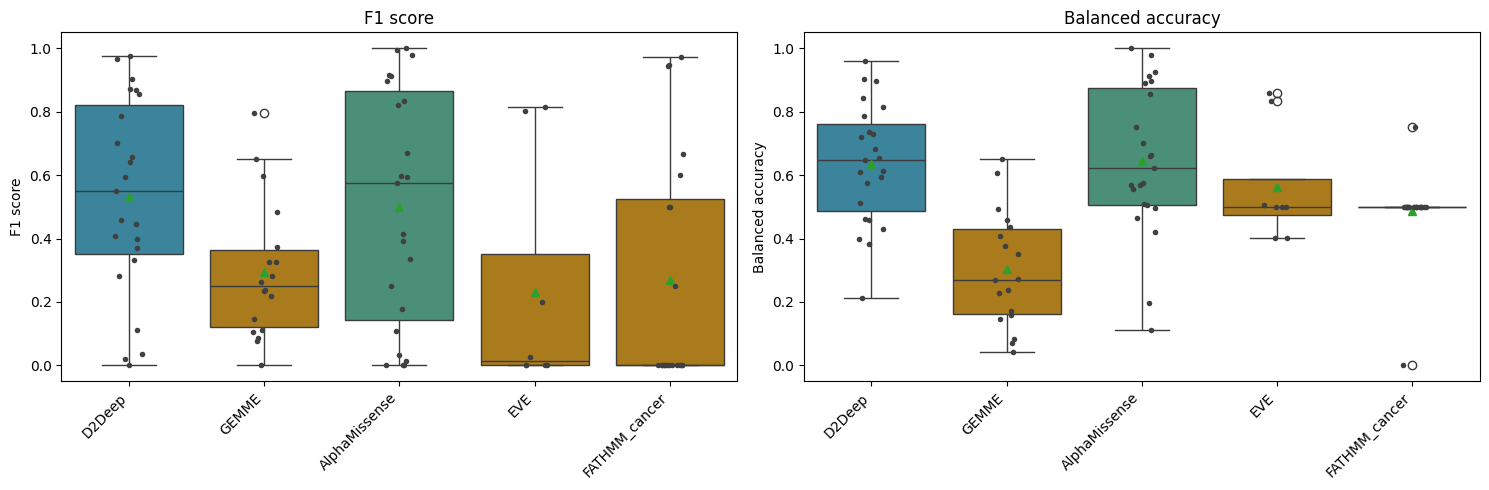

In [ ]:
order=list(RULES); #colors=sns.color_palette('tab10',len(order))
colors=['#2b8dab', '#C18305', '#409a7d', '#C18305', '#C18305']
fig,axes=plt.subplots(1,2,figsize=(15,5))
for ax,metric,title in [(axes[0],f1,'F1 score'),(axes[1],ba,'Balanced accuracy')]:
    data=[np.asarray(metric[k],float)[~np.isnan(np.asarray(metric[k],float))] for k in order]
    sns.boxplot(data=data,palette=list(colors), showmeans=True,ax=ax)
    sns.stripplot(data=data,color='.25',jitter=True,size=4,ax=ax)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order,rotation=45,ha='right'); ax.set_ylabel(title); ax.set_title(title)
plt.tight_layout(); plt.show()